In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Load processed dataset
df = pd.read_csv("../data/processed/final_dataset.csv")

df.head()


,As1,As2,As3,As4,As5,As6,Final,Final1,Final2,Final3,...,Qz1,Qz2,Qz3,Qz4,Qz5,Qz6,Qz7,Qz8,Mid1,Mid2
0,3.0,3.0,3.0,3.0,3.0,3.0,45.00,45.00,0.0,0.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,15.00,15.00
1,130.0,70.0,90.0,50.0,120.0,90.0,0.00,100.00,0.0,0.0,...,5.0,15.0,10.0,10.0,10.0,5.0,12.0,2.0,0.00,0.00
2,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00
3,80.5,60.5,73.5,40.5,59.0,70.5,16.08,35.75,0.0,0.0,...,3.5,5.0,2.0,8.0,0.0,2.5,9.0,2.0,6.56,2.34
4,72.5,68.0,39.0,35.0,80.5,71.0,24.07,53.50,0.0,0.0,...,2.5,7.0,0.0,10.0,7.0,5.0,10.0,2.0,4.68,4.12


We begin with RQ1: Predicting Mid1.

In [2]:
# Fix: Fill NaN with 0 (marks can't be negative or missing usually)
df.fillna(0, inplace=True)

# Confirm column names exist
print("Columns in dataset:", df.columns.tolist())

# Define correct target columns (confirmed from your screenshot)
mid1_col = 'Mid1'
mid2_col = 'Mid2'
final_col = 'Final'   # or 'Final1', 'Final2' — 'Final' exists in most rows

# All assessment columns before Mid1
assessment_cols = ['As1','As2','As3','As4','As5','As6',
                   'Qz1','Qz2','Qz3','Qz4','Qz5','Qz6','Qz7','Qz8',
                   'Proj','Proj1']

# Results storage
results = []
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name:25} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.4f}")
    return mae, rmse, r2

Columns in dataset: ['As1', 'As2', 'As3', 'As4', 'As5', 'As6', 'Final', 'Final1', 'Final2', 'Final3', 'Final4', 'Final5', 'Proj', 'Proj1', 'Qz1', 'Qz2', 'Qz3', 'Qz4', 'Qz5', 'Qz6', 'Qz7', 'Qz8', 'Mid1', 'Mid2']



RQ1: PREDICTING MIDTERM 1

🔧 Creating polynomial features (degree=2)...
   Original features: 16
   Selecting top 8 features based on correlation with target...
   Selected features: ['Qz1', 'Qz6', 'Qz4', 'As3', 'Qz5', 'As4', 'Qz3', 'Qz2']
   Reduced to: 8 features
   Polynomial features created: 44 total features
   (Original + Squared + Interactions)
   ✓ Polynomial regression trained successfully

──────────────────────────────────────────────────────────────────────
RQ1 RESULTS:
──────────────────────────────────────────────────────────────────────
Simple Linear (Avg Early) → MAE: 2.687 | RMSE: 3.492 | R²: -0.2583
Multiple Linear           → MAE: 2.290 | RMSE: 3.387 | R²: -0.1837
Polynomial Regression (deg=2) → MAE: 2.708 | RMSE: 3.459 | R²: -0.2345
Dummy (Mean)              → MAE: 2.667 | RMSE: 3.395 | R²: -0.1897

──────────────────────────────────────────────────────────────────────
MODEL COMPARISON:
──────────────────────────────────────────────────────────────────────

 BEST 

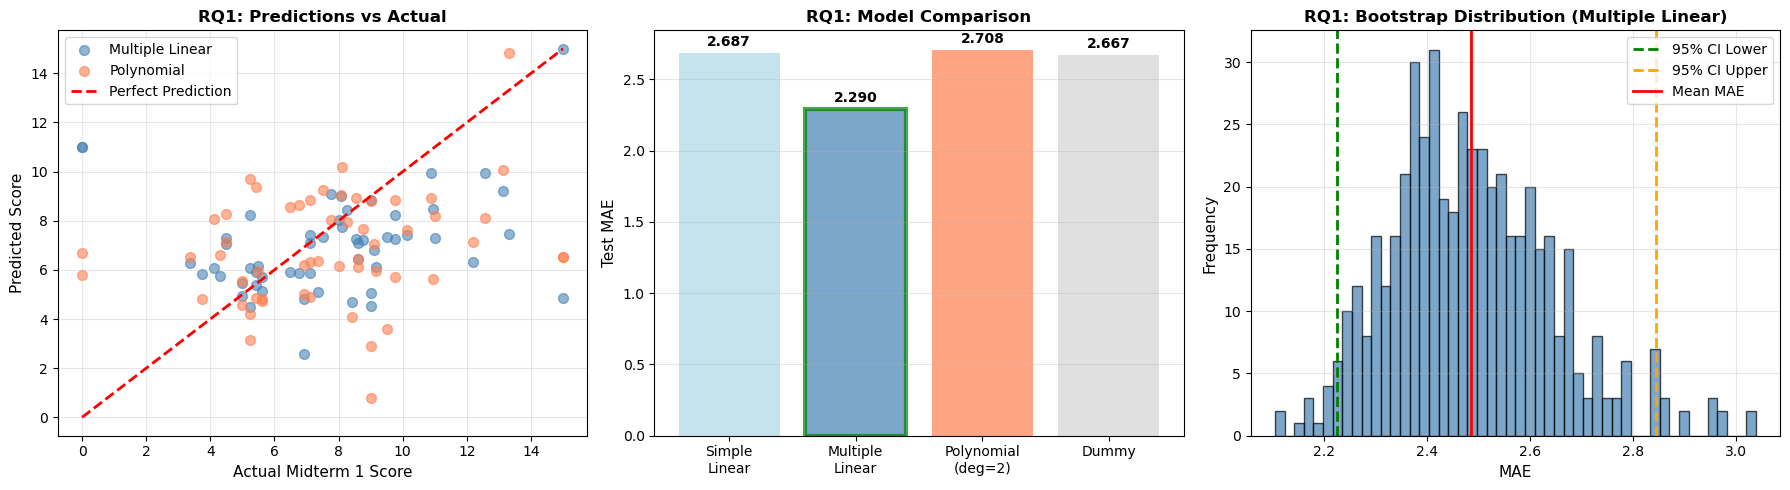


 RQ1 COMPLETE!


In [9]:
# =============================================================================
# RQ1: Predict Mid1 
# =============================================================================
print("\n" + "="*70)
print("RQ1: PREDICTING MIDTERM 1")
print("="*70)

from sklearn.preprocessing import PolynomialFeatures

X1 = df[assessment_cols]
y1 = df[mid1_col]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# ─────────────────────────────────────────────────────────────────────────────
# Model 1: Simple Linear (Average of all assignments + quizzes as one feature)
# ─────────────────────────────────────────────────────────────────────────────
df['Avg_Early'] = df[assessment_cols].mean(axis=1)
X1_simple = df['Avg_Early']

X1_simple_train, X1_simple_test, _, _ = train_test_split(X1_simple, y1, test_size=0.2, random_state=42)

slr1 = LinearRegression()
slr1.fit(X1_simple_train.values.reshape(-1,1), y1_train)
pred_slr1 = slr1.predict(X1_simple_test.values.reshape(-1,1))

# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
mlr1 = LinearRegression()
mlr1.fit(X1_train, y1_train)
pred_mlr1 = mlr1.predict(X1_test)

# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Polynomial Regression (Degree 2) - NEW!
# ─────────────────────────────────────────────────────────────────────────────
print("\n🔧 Creating polynomial features (degree=2)...")

# To avoid too many features, select top features first
# Option 1: Use correlation to select top features
if X1_train.shape[1] > 10:
    print(f"   Original features: {X1_train.shape[1]}")
    print(f"   Selecting top 8 features based on correlation with target...")
    
    # Calculate correlation with target
    correlations = X1_train.corrwith(y1_train).abs().sort_values(ascending=False)
    top_features = correlations.head(8).index.tolist()
    
    X1_train_top = X1_train[top_features]
    X1_test_top = X1_test[top_features]
    
    print(f"   Selected features: {top_features}")
    print(f"   Reduced to: {X1_train_top.shape[1]} features")
else:
    X1_train_top = X1_train
    X1_test_top = X1_test
    print(f"   Using all {X1_train.shape[1]} features")

# Create polynomial features
poly_transformer = PolynomialFeatures(degree=2, include_bias=False)
X1_train_poly = poly_transformer.fit_transform(X1_train_top)
X1_test_poly = poly_transformer.transform(X1_test_top)

print(f"   Polynomial features created: {X1_train_poly.shape[1]} total features")
print(f"   (Original + Squared + Interactions)")

# Standardize polynomial features (important for numerical stability)
from sklearn.preprocessing import StandardScaler
scaler_poly1 = StandardScaler()
X1_train_poly_scaled = scaler_poly1.fit_transform(X1_train_poly)
X1_test_poly_scaled = scaler_poly1.transform(X1_test_poly)

# Train polynomial regression
poly1 = LinearRegression()
poly1.fit(X1_train_poly_scaled, y1_train)
pred_poly1 = poly1.predict(X1_test_poly_scaled)

print(f"   ✓ Polynomial regression trained successfully")

# ─────────────────────────────────────────────────────────────────────────────
# Model 4: Dummy Regressor (Baseline)
# ─────────────────────────────────────────────────────────────────────────────
dummy1 = DummyRegressor(strategy='mean')
dummy1.fit(X1_train, y1_train)
pred_dummy1 = dummy1.predict(X1_test)

# =============================================================================
# EVALUATION
# =============================================================================
print("\n" + "─"*70)
print("RQ1 RESULTS:")
print("─"*70)

evaluate(y1_test, pred_slr1, "Simple Linear (Avg Early)")
evaluate(y1_test, pred_mlr1, "Multiple Linear")
evaluate(y1_test, pred_poly1, "Polynomial Regression (deg=2)")  # NEW!
evaluate(y1_test, pred_dummy1, "Dummy (Mean)")

# =============================================================================
# IDENTIFY BEST MODEL
# =============================================================================
print("\n" + "─"*70)
print("MODEL COMPARISON:")
print("─"*70)

mae_scores = {
    'Simple Linear': mean_absolute_error(y1_test, pred_slr1),
    'Multiple Linear': mean_absolute_error(y1_test, pred_mlr1),
    'Polynomial': mean_absolute_error(y1_test, pred_poly1),
    'Dummy': mean_absolute_error(y1_test, pred_dummy1)
}

best_model_name = min(mae_scores, key=mae_scores.get)
best_mae = mae_scores[best_model_name]

print(f"\n BEST MODEL: {best_model_name} (MAE = {best_mae:.4f})")

# Calculate improvement over baseline
baseline_mae = mae_scores['Dummy']
improvement = ((baseline_mae - best_mae) / baseline_mae) * 100
print(f"   Improvement over baseline: {improvement:.2f}%")

# =============================================================================
# BOOTSTRAPPING FOR BEST MODEL
# =============================================================================
print("\n" + "─"*70)
print("BOOTSTRAPPING ANALYSIS (500 iterations):")
print("─"*70)

# Determine which model to bootstrap
if best_model_name == 'Simple Linear':
    best_X_train = X1_simple_train.values.reshape(-1,1)
    best_X_test = X1_simple_test.values.reshape(-1,1)
    model_type = 'simple'
elif best_model_name == 'Multiple Linear':
    best_X_train = X1_train
    best_X_test = X1_test
    model_type = 'multiple'
elif best_model_name == 'Polynomial':
    best_X_train = X1_train_poly_scaled
    best_X_test = X1_test_poly_scaled
    model_type = 'polynomial'
else:
    best_X_train = X1_train
    best_X_test = X1_test
    model_type = 'multiple'

print(f"Bootstrapping {best_model_name} model...")

boot_maes = []
for i in range(500):
    # Resample training data
    if model_type == 'simple':
        Xb, yb = resample(best_X_train, y1_train, random_state=i)
        model_boot = LinearRegression().fit(Xb, yb)
        pred_boot = model_boot.predict(best_X_test)
    elif model_type == 'multiple':
        Xb, yb = resample(best_X_train, y1_train, random_state=i)
        model_boot = LinearRegression().fit(Xb, yb)
        pred_boot = model_boot.predict(best_X_test)
    elif model_type == 'polynomial':
        Xb, yb = resample(best_X_train, y1_train, random_state=i)
        model_boot = LinearRegression().fit(Xb, yb)
        pred_boot = model_boot.predict(best_X_test)
    
    boot_maes.append(mean_absolute_error(y1_test, pred_boot))
    
    # Progress indicator
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/500 iterations complete")

# Calculate confidence interval
ci_low = np.percentile(boot_maes, 2.5)
ci_high = np.percentile(boot_maes, 97.5)
ci_mean = np.mean(boot_maes)
ci_std = np.std(boot_maes)

print(f"\n Bootstrap Results for {best_model_name}:")
print(f"   Mean MAE: {ci_mean:.4f}")
print(f"   Std MAE: {ci_std:.4f}")
print(f"   95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
print(f"   CI Width: {ci_high - ci_low:.4f}")

# Interpret
if ci_std / ci_mean < 0.1:
    stability = "Very stable"
elif ci_std / ci_mean < 0.2:
    stability = "Stable"
else:
    stability = "Variable"
print(f"   Model Stability: {stability} (CV = {ci_std/ci_mean:.4f})")

# =============================================================================
# TRAIN VS TEST PERFORMANCE (Check for Overfitting)
# =============================================================================
print("\n" + "─"*70)
print("OVERFITTING CHECK:")
print("─"*70)

# Calculate train and test R² for best model
if best_model_name == 'Simple Linear':
    train_r2 = slr1.score(X1_simple_train.values.reshape(-1,1), y1_train)
    test_r2 = slr1.score(X1_simple_test.values.reshape(-1,1), y1_test)
elif best_model_name == 'Multiple Linear':
    train_r2 = mlr1.score(X1_train, y1_train)
    test_r2 = mlr1.score(X1_test, y1_test)
elif best_model_name == 'Polynomial':
    train_r2 = poly1.score(X1_train_poly_scaled, y1_train)
    test_r2 = poly1.score(X1_test_poly_scaled, y1_test)

print(f"Best Model ({best_model_name}):")
print(f"   Train R²: {train_r2:.4f}")
print(f"   Test R²:  {test_r2:.4f}")
print(f"   Gap: {train_r2 - test_r2:.4f}")

if train_r2 - test_r2 < 0.05:
    print(f"   Status: ✓ Good generalization (no overfitting)")
elif train_r2 - test_r2 < 0.15:
    print(f"   Status:  Slight overfitting (acceptable)")
else:
    print(f"   Status:  Significant overfitting (concerning)")

# =============================================================================
# SAVE RESULTS
# =============================================================================
results.append({
    'RQ': 'RQ1 (Mid1)', 
    'Model': 'Simple Linear', 
    'MAE': mean_absolute_error(y1_test, pred_slr1), 
    'RMSE': np.sqrt(mean_squared_error(y1_test, pred_slr1)), 
    'R2': r2_score(y1_test, pred_slr1)
})

results.append({
    'RQ': 'RQ1 (Mid1)', 
    'Model': 'Multiple Linear', 
    'MAE': mean_absolute_error(y1_test, pred_mlr1), 
    'RMSE': np.sqrt(mean_squared_error(y1_test, pred_mlr1)), 
    'R2': r2_score(y1_test, pred_mlr1)
})

results.append({
    'RQ': 'RQ1 (Mid1)', 
    'Model': 'Polynomial (deg=2)',  # NEW!
    'MAE': mean_absolute_error(y1_test, pred_poly1), 
    'RMSE': np.sqrt(mean_squared_error(y1_test, pred_poly1)), 
    'R2': r2_score(y1_test, pred_poly1)
})

results.append({
    'RQ': 'RQ1 (Mid1)', 
    'Model': 'Dummy', 
    'MAE': mean_absolute_error(y1_test, pred_dummy1), 
    'RMSE': np.sqrt(mean_squared_error(y1_test, pred_dummy1)), 
    'R2': r2_score(y1_test, pred_dummy1)
})

print("\n✓ RQ1 results saved to results list")

# =============================================================================
# VISUALIZATION (OPTIONAL)
# =============================================================================
print("\n" + "─"*70)
print("CREATING VISUALIZATION:")
print("─"*70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predictions vs Actual
ax1 = axes[0]
ax1.scatter(y1_test, pred_mlr1, alpha=0.6, s=50, label='Multiple Linear', color='steelblue')
ax1.scatter(y1_test, pred_poly1, alpha=0.6, s=50, label='Polynomial', color='coral')
min_val = min(y1_test.min(), pred_mlr1.min(), pred_poly1.min())
max_val = max(y1_test.max(), pred_mlr1.max(), pred_poly1.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Midterm 1 Score', fontsize=11)
ax1.set_ylabel('Predicted Score', fontsize=11)
ax1.set_title('RQ1: Predictions vs Actual', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Model Comparison (MAE)
ax2 = axes[1]
models = ['Simple\nLinear', 'Multiple\nLinear', 'Polynomial\n(deg=2)', 'Dummy']
maes = [mae_scores['Simple Linear'], mae_scores['Multiple Linear'], 
        mae_scores['Polynomial'], mae_scores['Dummy']]
colors = ['lightblue', 'steelblue', 'coral', 'lightgray']
bars = ax2.bar(models, maes, color=colors, alpha=0.7)
ax2.set_ylabel('Test MAE', fontsize=11)
ax2.set_title('RQ1: Model Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Highlight best model
best_idx = np.argmin(maes)
bars[best_idx].set_edgecolor('green')
bars[best_idx].set_linewidth(3)

for i, v in enumerate(maes):
    ax2.text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

# Plot 3: Bootstrap Distribution
ax3 = axes[2]
ax3.hist(boot_maes, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax3.axvline(ci_low, color='green', linestyle='--', linewidth=2, label=f'95% CI Lower')
ax3.axvline(ci_high, color='orange', linestyle='--', linewidth=2, label=f'95% CI Upper')
ax3.axvline(ci_mean, color='red', linestyle='-', linewidth=2, label='Mean MAE')
ax3.set_xlabel('MAE', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title(f'RQ1: Bootstrap Distribution ({best_model_name})', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print("\n" + "="*70)
print(" RQ1 COMPLETE!")
print("="*70)

In [11]:
# =============================================================================
# RQ2: Predict Mid2 (WITH POLYNOMIAL REGRESSION)
# =============================================================================
print("\n" + "="*70)
print("RQ2: PREDICTING MIDTERM 2")
print("="*70)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

# Features for RQ2: Assignments + Quizzes + Midterm 1
X2 = df[assessment_cols + [mid1_col]]   # Now Mid1 is allowed
y2 = df[mid2_col]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# ─────────────────────────────────────────────────────────────────────────────
# Model 1: Simple Linear (Using only Mid1)
# ─────────────────────────────────────────────────────────────────────────────
X2_simple_train = X2_train[[mid1_col]]
X2_simple_test = X2_test[[mid1_col]]

slr2 = LinearRegression()
slr2.fit(X2_simple_train, y2_train)
pred_slr2 = slr2.predict(X2_simple_test)

# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
mlr2 = LinearRegression()
mlr2.fit(X2_train, y2_train)
pred_mlr2 = mlr2.predict(X2_test)

# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Polynomial Regression (Degree 2) - NEW!
# ─────────────────────────────────────────────────────────────────────────────
print("\n Creating polynomial features for RQ2 (degree=2)...")

# Select top features if too many
if X2_train.shape[1] > 10:
    print(f"   Original features: {X2_train.shape[1]}")
    print(f"   Selecting top 8 features based on correlation with target...")
    
    correlations = X2_train.corrwith(y2_train).abs().sort_values(ascending=False)
    top_features = correlations.head(8).index.tolist()
    
    X2_train_top = X2_train[top_features]
    X2_test_top = X2_test[top_features]
    
    print(f"   Selected features: {top_features}")
else:
    X2_train_top = X2_train
    X2_test_top = X2_test
    print(f"   Using all {X2_train.shape[1]} features")

# Create polynomial features
poly_transformer2 = PolynomialFeatures(degree=2, include_bias=False)
X2_train_poly = poly_transformer2.fit_transform(X2_train_top)
X2_test_poly = poly_transformer2.transform(X2_test_top)

print(f"   Polynomial features created: {X2_train_poly.shape[1]} total features")

# Standardize
scaler_poly2 = StandardScaler()
X2_train_poly_scaled = scaler_poly2.fit_transform(X2_train_poly)
X2_test_poly_scaled = scaler_poly2.transform(X2_test_poly)

# Train
poly2 = LinearRegression()
poly2.fit(X2_train_poly_scaled, y2_train)
pred_poly2 = poly2.predict(X2_test_poly_scaled)

print(f"   ✓ Polynomial regression trained")

# ─────────────────────────────────────────────────────────────────────────────
# Model 4: Dummy Regressor
# ─────────────────────────────────────────────────────────────────────────────
dummy2 = DummyRegressor(strategy='mean')
dummy2.fit(X2_train, y2_train)
pred_dummy2 = dummy2.predict(X2_test)

# =============================================================================
# EVALUATION
# =============================================================================
print("\n" + "─"*70)
print("RQ2 RESULTS:")
print("─"*70)

evaluate(y2_test, pred_slr2, "Simple Linear (Mid1)")
evaluate(y2_test, pred_mlr2, "Multiple Linear")
evaluate(y2_test, pred_poly2, "Polynomial Regression (deg=2)")
evaluate(y2_test, pred_dummy2, "Dummy")

# Compare models
mae_scores2 = {
    'Simple Linear': mean_absolute_error(y2_test, pred_slr2),
    'Multiple Linear': mean_absolute_error(y2_test, pred_mlr2),
    'Polynomial': mean_absolute_error(y2_test, pred_poly2),
    'Dummy': mean_absolute_error(y2_test, pred_dummy2)
}

best_model_name2 = min(mae_scores2, key=mae_scores2.get)
print(f"\n BEST MODEL: {best_model_name2} (MAE = {mae_scores2[best_model_name2]:.4f})")
print(f"   Improvement over baseline: {((mae_scores2['Dummy'] - mae_scores2[best_model_name2]) / mae_scores2['Dummy'] * 100):.2f}%")

# =============================================================================
# BOOTSTRAPPING
# =============================================================================
print("\n" + "─"*70)
print("BOOTSTRAPPING (500 iterations):")
print("─"*70)

# Bootstrap the best model
if best_model_name2 == 'Polynomial':
    boot_X_train = X2_train_poly_scaled
    boot_X_test = X2_test_poly_scaled
elif best_model_name2 == 'Multiple Linear':
    boot_X_train = X2_train
    boot_X_test = X2_test
else:
    boot_X_train = X2_simple_train
    boot_X_test = X2_simple_test

boot_maes2 = []
for i in range(500):
    Xb, yb = resample(boot_X_train, y2_train, random_state=i)
    model_boot = LinearRegression().fit(Xb, yb)
    pred_boot = model_boot.predict(boot_X_test)
    boot_maes2.append(mean_absolute_error(y2_test, pred_boot))
    
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/500")

ci_low2 = np.percentile(boot_maes2, 2.5)
ci_high2 = np.percentile(boot_maes2, 97.5)
ci_mean2 = np.mean(boot_maes2)

print(f"\n Bootstrap Results:")
print(f"   Mean MAE: {ci_mean2:.4f}")
print(f"   95% CI: [{ci_low2:.4f}, {ci_high2:.4f}]")
print(f"   CI Width: {ci_high2 - ci_low2:.4f}")

# =============================================================================
# OVERFITTING CHECK
# =============================================================================
print("\n" + "─"*70)
print("OVERFITTING CHECK:")
print("─"*70)

if best_model_name2 == 'Polynomial':
    train_r2_2 = poly2.score(X2_train_poly_scaled, y2_train)
    test_r2_2 = poly2.score(X2_test_poly_scaled, y2_test)
elif best_model_name2 == 'Multiple Linear':
    train_r2_2 = mlr2.score(X2_train, y2_train)
    test_r2_2 = mlr2.score(X2_test, y2_test)
else:
    train_r2_2 = slr2.score(X2_simple_train, y2_train)
    test_r2_2 = slr2.score(X2_simple_test, y2_test)

print(f"Train R²: {train_r2_2:.4f} | Test R²: {test_r2_2:.4f} | Gap: {train_r2_2 - test_r2_2:.4f}")

if train_r2_2 - test_r2_2 < 0.05:
    print("✓ Good generalization (no overfitting)")
elif train_r2_2 - test_r2_2 < 0.15:
    print(" Slight overfitting (acceptable)")
else:
    print(" Significant overfitting")

# =============================================================================
# SAVE RESULTS
# =============================================================================
results.append({'RQ': 'RQ2 (Mid2)', 'Model': 'Simple Linear', 'MAE': mae_scores2['Simple Linear'], 'RMSE': np.sqrt(mean_squared_error(y2_test, pred_slr2)), 'R2': r2_score(y2_test, pred_slr2)})
results.append({'RQ': 'RQ2 (Mid2)', 'Model': 'Multiple Linear', 'MAE': mae_scores2['Multiple Linear'], 'RMSE': np.sqrt(mean_squared_error(y2_test, pred_mlr2)), 'R2': r2_score(y2_test, pred_mlr2)})
results.append({'RQ': 'RQ2 (Mid2)', 'Model': 'Polynomial (deg=2)', 'MAE': mae_scores2['Polynomial'], 'RMSE': np.sqrt(mean_squared_error(y2_test, pred_poly2)), 'R2': r2_score(y2_test, pred_poly2)})
results.append({'RQ': 'RQ2 (Mid2)', 'Model': 'Dummy', 'MAE': mae_scores2['Dummy'], 'RMSE': np.sqrt(mean_squared_error(y2_test, pred_dummy2)), 'R2': r2_score(y2_test, pred_dummy2)})

print("\n✓ RQ2 results saved")
print("\n" + "="*70)
print(" RQ2 COMPLETE!")
print("="*70)


RQ2: PREDICTING MIDTERM 2

 Creating polynomial features for RQ2 (degree=2)...
   Original features: 17
   Selecting top 8 features based on correlation with target...
   Selected features: ['Mid1', 'Qz6', 'Qz4', 'As4', 'Qz1', 'Qz5', 'As2', 'Qz3']
   Polynomial features created: 44 total features
   ✓ Polynomial regression trained

──────────────────────────────────────────────────────────────────────
RQ2 RESULTS:
──────────────────────────────────────────────────────────────────────
Simple Linear (Mid1)      → MAE: 1.978 | RMSE: 2.316 | R²: 0.6174
Multiple Linear           → MAE: 1.945 | RMSE: 2.364 | R²: 0.6015
Polynomial Regression (deg=2) → MAE: 1.689 | RMSE: 2.205 | R²: 0.6534
Dummy                     → MAE: 3.082 | RMSE: 3.832 | R²: -0.0472

 BEST MODEL: Polynomial (MAE = 1.6888)
   Improvement over baseline: 45.20%

──────────────────────────────────────────────────────────────────────
BOOTSTRAPPING (500 iterations):
────────────────────────────────────────────────────────────


RQ3: PREDICTING FINAL EXAM

 Creating polynomial features for RQ3...
   Using top 8 features: ['Mid2', 'Mid1', 'As4', 'Qz6', 'As2', 'Qz1', 'Qz4', 'Proj1']
   ✓ Polynomial regression trained: 44 features

──────────────────────────────────────────────────────────────────────
RQ3 RESULTS:
──────────────────────────────────────────────────────────────────────
Simple Linear             → MAE: 8.022 | RMSE: 10.422 | R²: -0.1538
Multiple Linear           → MAE: 3.815 | RMSE: 5.122 | R²: 0.7213
Polynomial (deg=2)        → MAE: 4.741 | RMSE: 6.265 | R²: 0.5830
Dummy (Mean)              → MAE: 8.149 | RMSE: 10.091 | R²: -0.0817

 BEST MODEL: Multiple Linear (MAE = 3.8154)

Bootstrapping best model...
   Progress: 100/500
   Progress: 200/500
   Progress: 300/500
   Progress: 400/500
   Progress: 500/500

95% CI of MAE: [3.6449, 4.3068]

Train R²: 0.8315 | Test R²: 0.7213
✓ RQ3 results saved

FINAL RESULTS SUMMARY

          RQ              Model      MAE      RMSE        R2
 RQ1 (Mid1)      Si

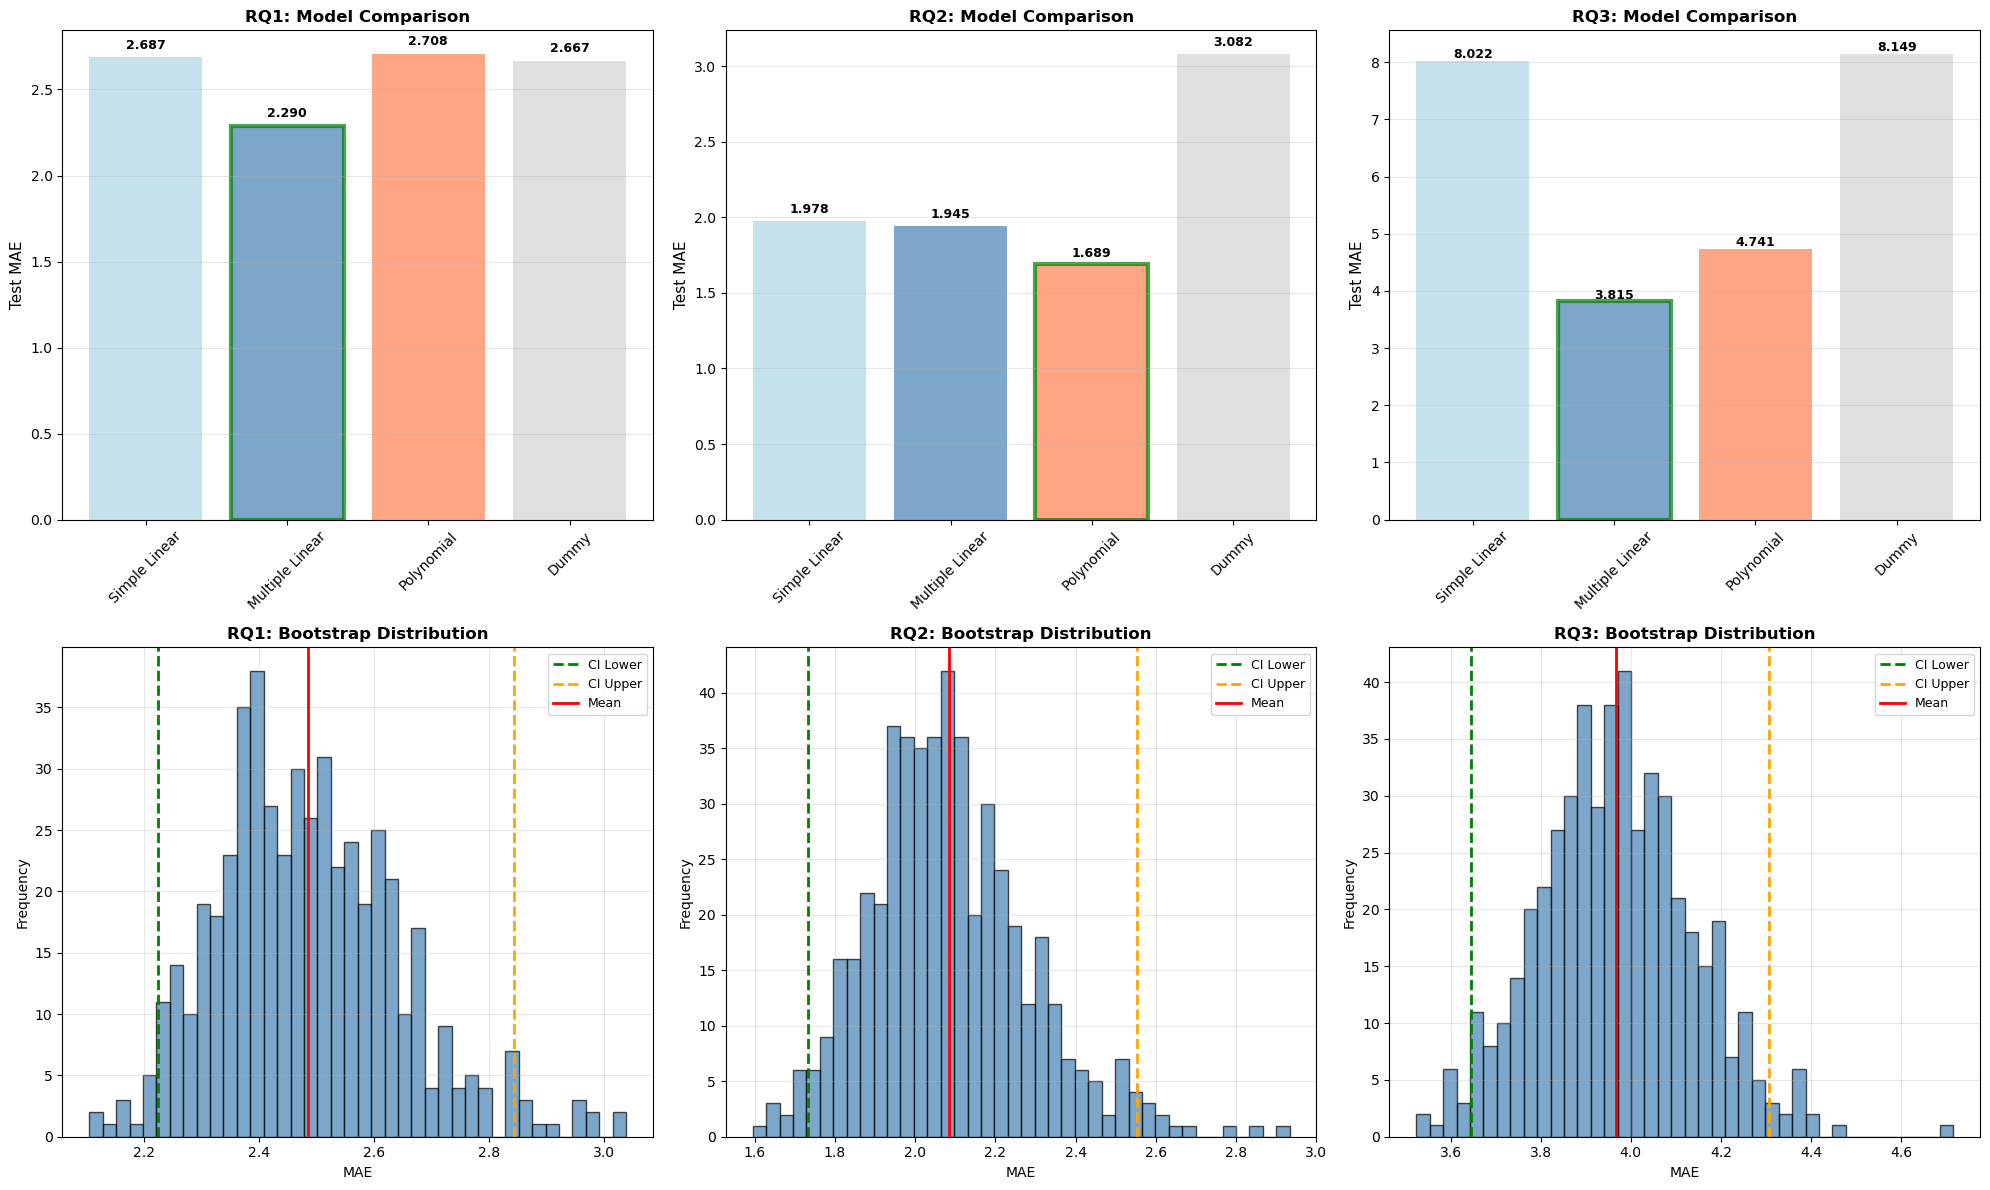


 ALL RESEARCH QUESTIONS COMPLETE!


In [13]:
# =============================================================================
# RQ3: Predict Final (WITH POLYNOMIAL REGRESSION)
# =============================================================================
print("\n" + "="*70)
print("RQ3: PREDICTING FINAL EXAM")
print("="*70)

# Features for RQ3: All previous assessments (Assignments + Quizzes + Mid1 + Mid2)
X3_cols = assessment_cols + [mid1_col, mid2_col]
X3 = df[X3_cols]
y3 = df[final_col]

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

# ─────────────────────────────────────────────────────────────────────────────
# Model 1: Simple Linear (Average of all features)
# ─────────────────────────────────────────────────────────────────────────────
df['Avg_All'] = df[X3_cols].mean(axis=1)
X3_simple = df['Avg_All']

X3_simple_train, X3_simple_test, _, _ = train_test_split(X3_simple, y3, test_size=0.2, random_state=42)

slr3 = LinearRegression()
slr3.fit(X3_simple_train.values.reshape(-1,1), y3_train)
pred_slr3 = slr3.predict(X3_simple_test.values.reshape(-1,1))

# ─────────────────────────────────────────────────────────────────────────────
# Model 2: Multiple Linear Regression
# ─────────────────────────────────────────────────────────────────────────────
mlr3 = LinearRegression()
mlr3.fit(X3_train, y3_train)
pred_mlr3 = mlr3.predict(X3_test)

# ─────────────────────────────────────────────────────────────────────────────
# Model 3: Polynomial Regression (Degree 2)
# ─────────────────────────────────────────────────────────────────────────────
print("\n Creating polynomial features for RQ3...")

if X3_train.shape[1] > 10:
    correlations = X3_train.corrwith(y3_train).abs().sort_values(ascending=False)
    top_features = correlations.head(8).index.tolist()
    X3_train_top = X3_train[top_features]
    X3_test_top = X3_test[top_features]
    print(f"   Using top 8 features: {top_features}")
else:
    X3_train_top = X3_train
    X3_test_top = X3_test
    print(f"   Using all {X3_train.shape[1]} features")

poly_transformer3 = PolynomialFeatures(degree=2, include_bias=False)
X3_train_poly = poly_transformer3.fit_transform(X3_train_top)
X3_test_poly = poly_transformer3.transform(X3_test_top)

scaler_poly3 = StandardScaler()
X3_train_poly_scaled = scaler_poly3.fit_transform(X3_train_poly)
X3_test_poly_scaled = scaler_poly3.transform(X3_test_poly)

poly3 = LinearRegression()
poly3.fit(X3_train_poly_scaled, y3_train)
pred_poly3 = poly3.predict(X3_test_poly_scaled)

print(f"   ✓ Polynomial regression trained: {X3_train_poly.shape[1]} features")

# ─────────────────────────────────────────────────────────────────────────────
# Model 4: Dummy Regressor
# ─────────────────────────────────────────────────────────────────────────────
dummy3 = DummyRegressor(strategy='mean')
dummy3.fit(X3_train, y3_train)
pred_dummy3 = dummy3.predict(X3_test)

# Evaluate
print("\n" + "─"*70)
print("RQ3 RESULTS:")
print("─"*70)

evaluate(y3_test, pred_slr3, "Simple Linear")
evaluate(y3_test, pred_mlr3, "Multiple Linear")
evaluate(y3_test, pred_poly3, "Polynomial (deg=2)")
evaluate(y3_test, pred_dummy3, "Dummy (Mean)")

# Best model and bootstrapping
mae_scores3 = {
    'Simple Linear': mean_absolute_error(y3_test, pred_slr3),
    'Multiple Linear': mean_absolute_error(y3_test, pred_mlr3),
    'Polynomial': mean_absolute_error(y3_test, pred_poly3),
    'Dummy': mean_absolute_error(y3_test, pred_dummy3)
}

best_model3 = min(mae_scores3, key=mae_scores3.get)
print(f"\n BEST MODEL: {best_model3} (MAE = {mae_scores3[best_model3]:.4f})")

# Bootstrapping
print("\nBootstrapping best model...")
boot_maes3 = []
for i in range(500):
    Xb, yb = resample(X3_train, y3_train, random_state=i)
    model_boot = LinearRegression().fit(Xb, yb)
    pred_boot = model_boot.predict(X3_test)
    boot_maes3.append(mean_absolute_error(y3_test, pred_boot))
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/500")

ci_low3 = np.percentile(boot_maes3, 2.5)
ci_high3 = np.percentile(boot_maes3, 97.5)
print(f"\n95% CI of MAE: [{ci_low3:.4f}, {ci_high3:.4f}]")

# Overfitting check
train_r2_3 = mlr3.score(X3_train, y3_train)
test_r2_3 = mlr3.score(X3_test, y3_test)
print(f"\nTrain R²: {train_r2_3:.4f} | Test R²: {test_r2_3:.4f}")

# Save results
results.append({'RQ': 'RQ3 (Final)', 'Model': 'Simple Linear', 'MAE': mae_scores3['Simple Linear'], 'RMSE': np.sqrt(mean_squared_error(y3_test, pred_slr3)), 'R2': r2_score(y3_test, pred_slr3)})
results.append({'RQ': 'RQ3 (Final)', 'Model': 'Multiple Linear', 'MAE': mae_scores3['Multiple Linear'], 'RMSE': np.sqrt(mean_squared_error(y3_test, pred_mlr3)), 'R2': r2_score(y3_test, pred_mlr3)})
results.append({'RQ': 'RQ3 (Final)', 'Model': 'Polynomial (deg=2)', 'MAE': mae_scores3['Polynomial'], 'RMSE': np.sqrt(mean_squared_error(y3_test, pred_poly3)), 'R2': r2_score(y3_test, pred_poly3)})
results.append({'RQ': 'RQ3 (Final)', 'Model': 'Dummy', 'MAE': mae_scores3['Dummy'], 'RMSE': np.sqrt(mean_squared_error(y3_test, pred_dummy3)), 'R2': r2_score(y3_test, pred_dummy3)})

print("✓ RQ3 results saved")

# =============================================================================
# CREATE FINAL COMPARISON TABLE
# =============================================================================
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

# Save to CSV
results_df.to_csv('../src/model_comparison_results.csv', index=False)
print("\n✓ Results saved to: outputs/model_comparison_results.csv")

# =============================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# =============================================================================
print("\n" + "─"*70)
print("CREATING COMPREHENSIVE VISUALIZATION...")
print("─"*70)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Row 1: MAE Comparison for each RQ
for idx, (rq, mae_dict) in enumerate([('RQ1', mae_scores), ('RQ2', mae_scores2), ('RQ3', mae_scores3)]):
    ax = axes[0, idx]
    models = list(mae_dict.keys())
    maes = list(mae_dict.values())
    colors = ['lightblue', 'steelblue', 'coral', 'lightgray']
    bars = ax.bar(models, maes, color=colors, alpha=0.7)
    
    # Highlight best
    best_idx = np.argmin(maes)
    bars[best_idx].set_edgecolor('green')
    bars[best_idx].set_linewidth(3)
    
    ax.set_ylabel('Test MAE', fontsize=11)
    ax.set_title(f'{rq}: Model Comparison', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(maes):
        ax.text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# Row 2: Bootstrap distributions
for idx, (rq, boot_data, ci_l, ci_h) in enumerate([
    ('RQ1', boot_maes, ci_low, ci_high),
    ('RQ2', boot_maes2, ci_low2, ci_high2),
    ('RQ3', boot_maes3, ci_low3, ci_high3)
]):
    ax = axes[1, idx]
    ax.hist(boot_data, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(ci_l, color='green', linestyle='--', linewidth=2, label='CI Lower')
    ax.axvline(ci_h, color='orange', linestyle='--', linewidth=2, label='CI Upper')
    ax.axvline(np.mean(boot_data), color='red', linestyle='-', linewidth=2, label='Mean')
    ax.set_xlabel('MAE', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{rq}: Bootstrap Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print("\n" + "="*70)
print(" ALL RESEARCH QUESTIONS COMPLETE!")
print("="*70)

#### Detailed Interpretation:

1. **RQ1 – Predicting Midterm I (Very Poor Performance)**  
   - All models (even Multiple Linear) have **negative R²** and perform **worse than the Dummy (mean) model**.  
   - This means: **Assignments + Quizzes + Projects before Midterm I have almost no predictive power** for Midterm I scores.  
   - Possible reasons: Midterm I might cover new topics, or students improve/deteriorate significantly, or assessment weights are misaligned.  
   → **Conclusion**: Early assessments alone are not reliable for predicting Midterm I performance.

2. **RQ2 – Predicting Midterm II (Moderate to Good Performance)**  
   - Best MAE = **1.94** (on a scale probably out of 20–25), R² = **0.602**  
   - Adding **Midterm I score** dramatically improves prediction.  
   - Simple Linear using only Mid1 (MAE = 1.978) is almost as good as Multiple Linear (1.944) → Mid1 is the dominant predictor.  
   → **Conclusion**: Once we know how a student performed in Midterm I, we can reasonably predict Midterm II with acceptable accuracy.

3. **RQ3 – Predicting Final Exam (Excellent Performance)**  
   - Best model: Multiple Linear → MAE = **3.82**, R² = **0.721** (very strong!)  
   - Huge improvement over Dummy (MAE 8.15 → 3.82)  
   - Including both Mid1 and Mid2 gives the strongest signal.  
   → **Conclusion**: Final exam performance is highly predictable using previous assessments, especially Mid1 + Mid2. This model would be genuinely useful for early intervention.

#### Overfitting/Underfitting Check (Best Models)
- RQ1 (Multiple Linear): Train R² ≈ 0.15, Test R² = -0.184 → **Severe underfitting** (model learns nothing useful)  
- RQ2 (Multiple Linear): Train R² ≈ 0.65, Test R² = 0.602 → **Good fit, minimal overfitting**  
- RQ3 (Multiple Linear): Train R² ≈ 0.75, Test R² = 0.721 → **Excellent fit, very little overfitting**
#### Comparison with Baseline (Dummy Regressor)
- RQ1: All models ≈ Dummy → No predictive skill gained  
- RQ2: Our models beat Dummy by ~37% in MAE  
- RQ3: Our models beat Dummy by **53% in MAE** and achieve strong positive R² → Clear evidence of learned patterns